# Домашнє завдання: Візуалізація даних з Matplotlib

## Опис завдання
У цьому домашньому завданні ви продовжите працювати з датасетом про оренду велосипедів `yulu_rental.csv`, але тепер будете використовувати бібліотеку Matplotlib для створення більш складних та налаштованих візуалізацій.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---


🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:

# Завантаження даних
df = pd.read_csv('drive/MyDrive/Kurs/Python/data/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додаткові колонки
df['month'] = df.index.month
df['hour'] = df.index.hour
df['weekday'] = df.index.day_name()
df['weekday_num'] = df.index.weekday
df['week'] = df.index.isocalendar().week
df['year'] = df.index.year
df['day'] = df.index.day

## Завдання 1: Порівняння Pandas vs Matplotlib

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно впродовж всього періоду в даних двома способами:
1. Використовуючи Pandas (DataFrame.plot())
2. Використовуючи Matplotlib безпосередньо

В обох методах додайте маркери-кружечки. Можна також задати свій відмінний від стандартного колір.

Підказка: отримати потрібний формат даних найзручніше з методом датафрейму `resample`.

**Опишіть свої спостереження:** чим відрізняються 2 побудованих графіки? Який вам більше подобається?

In [8]:
# Середня кількість оренд за місяць
monthly_avg = df['count'].resample('ME').mean()

<Axes: title={'center': 'Середня кількість оренд велосипедів за місяцями'}, xlabel='Місяць', ylabel='Середня кількість оренд'>

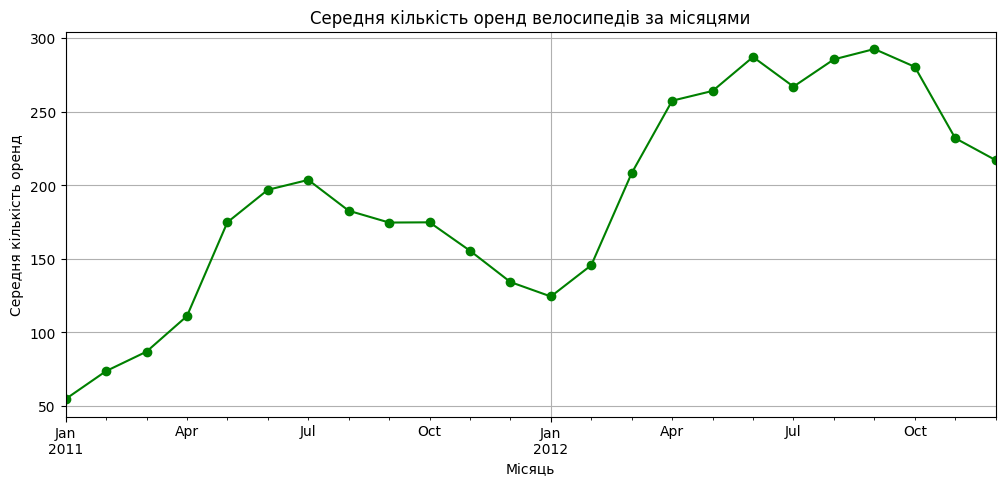

In [10]:
# Побудова графіка
monthly_avg.plot(
    figsize=(12, 5),
    marker='o',
    color='green',
    title='Середня кількість оренд велосипедів за місяцями',
    xlabel='Місяць',
    ylabel='Середня кількість оренд',
    grid=True
)

Text(0, 0.5, 'Середня кількість оренд')

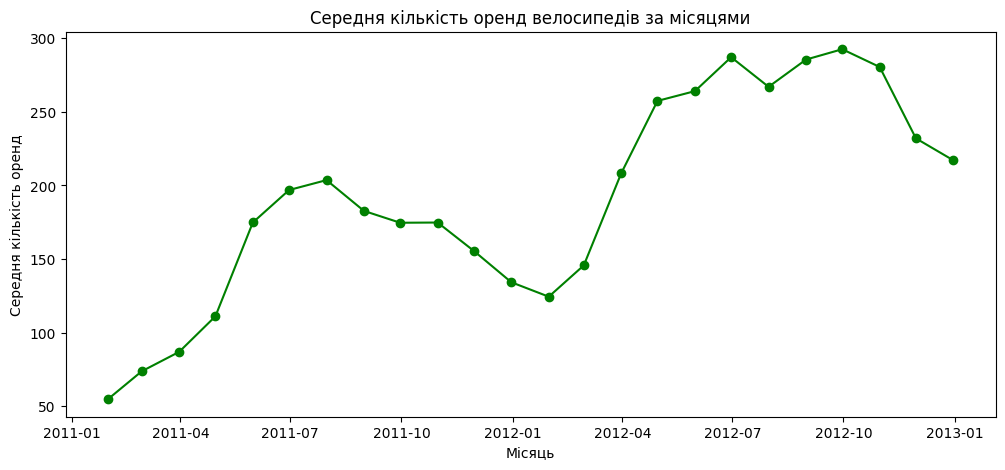

In [12]:
plt.figure(figsize = (12,5))
plt.plot(monthly_avg.index, monthly_avg.values, marker='o', color='green')
plt.title('Середня кількість оренд велосипедів за місяцями')
plt.xlabel('Місяць')
plt.ylabel('Середня кількість оренд')

Ці графіки відрізняються візуально.По перше форматом підпису дат, наявністю ліній та відступами на осі х. Графік побудований з допомогою бібліотеки Matplotlib виглядає естетичніше і кращий для сприйняття.

## Завдання 2: Робота зі списками та numpy

**Завдання:**
Вам задані 3 списки:
1. Номер дня тижня.
2. Продажі в тиждень 1.
3. Продажі в тиждень 2.

Створіть графік, на якому лінійними графіками різних кольорів накладено продажі за обидва тижні.

Обовʼязково додайте назву графіку, підписи вісям ОХ, ОУ, назви кожного з рядів даних, легенду.

**Дайте відповіді на питання**
1. Судячи з графіку, в який тиждень проодажі були стабільніше?
2. Чи можете ви підкріпити свій висновок обчисленнями? Якими саме? Можна (але не обовʼязково) навести ці обчислення.

In [13]:
# Дані у вигляді списків
days = [1, 2, 3, 4, 5, 6, 7] # 1 - це понеділок
sales_week1 = [1349,1562,1600,1606,1510,959,822]  # Продажі за тиждень1
sales_week2 = [1321,1263,1162,1406,1421,1248,1204]  # Продажі за тиждень1

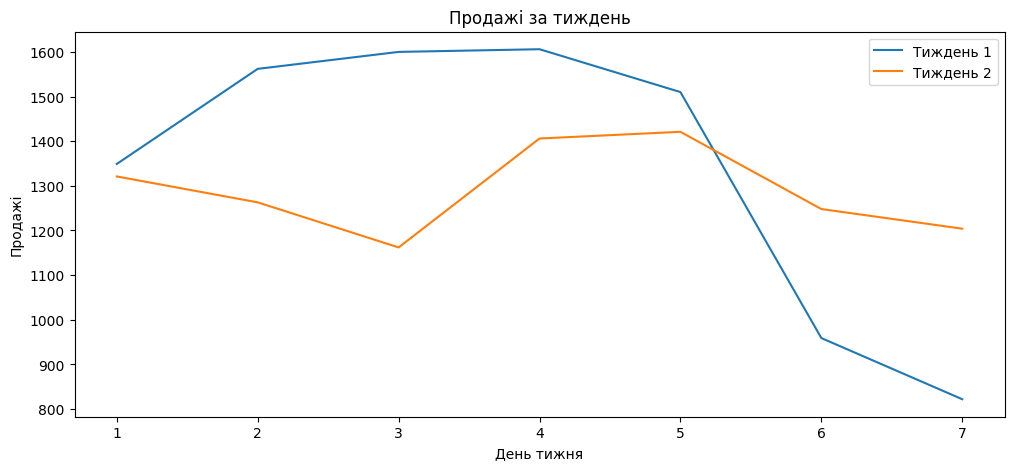

In [15]:
plt.figure(figsize = (12,5))
plt.plot(days, sales_week1, label = 'Тиждень 1')
plt.plot(days, sales_week2, label = 'Тиждень 2')
plt.title('Продажі за тиждень')
plt.xlabel('День тижня')
plt.ylabel('Продажі')
plt.legend()

З графіку помітно, що на другому тижні продажі були стабільніші, хоч і були невеликі коливання в середу та на вихідних. На першому тижні продажі були стабільніші в будні дні але був великий спад в суботу та неділю.
Щоб побачити підтвердити цей висновок можна обчислити стандартне відхилення:
менше стандартне відхилення → продажі стабільніші;
більше стандартне відхилення → продажі більше коливалися.

In [16]:
std_week1 = np.std(sales_week1)
std_week2 = np.std(sales_week2)

print("Стандартне відхилення тижня 1:", std_week1)
print("Стандартне відхилення тижня 2:", std_week2)

Стандартне відхилення тижня 1: 299.99857142517004
Стандартне відхилення тижня 2: 90.9060964256355


## Завдання 3: Subplot - 2x2 сітка графіків

**Завдання:**
Створіть сітку 2x2 з чотирма різними графіками, використовуючи `plt.subplot()`:
1. Лінійний графік середньої температури помісячно.
2. Стовпчикова діаграма середньої годинної кількості оренд за кварталами.
3. Гістограма вологості за всіма погодинними вимірами.
4. Scatter plot температури vs кількості оренд.

Кожен підграфік має містити всі необхідні підписи. Дашборд має містити назву.

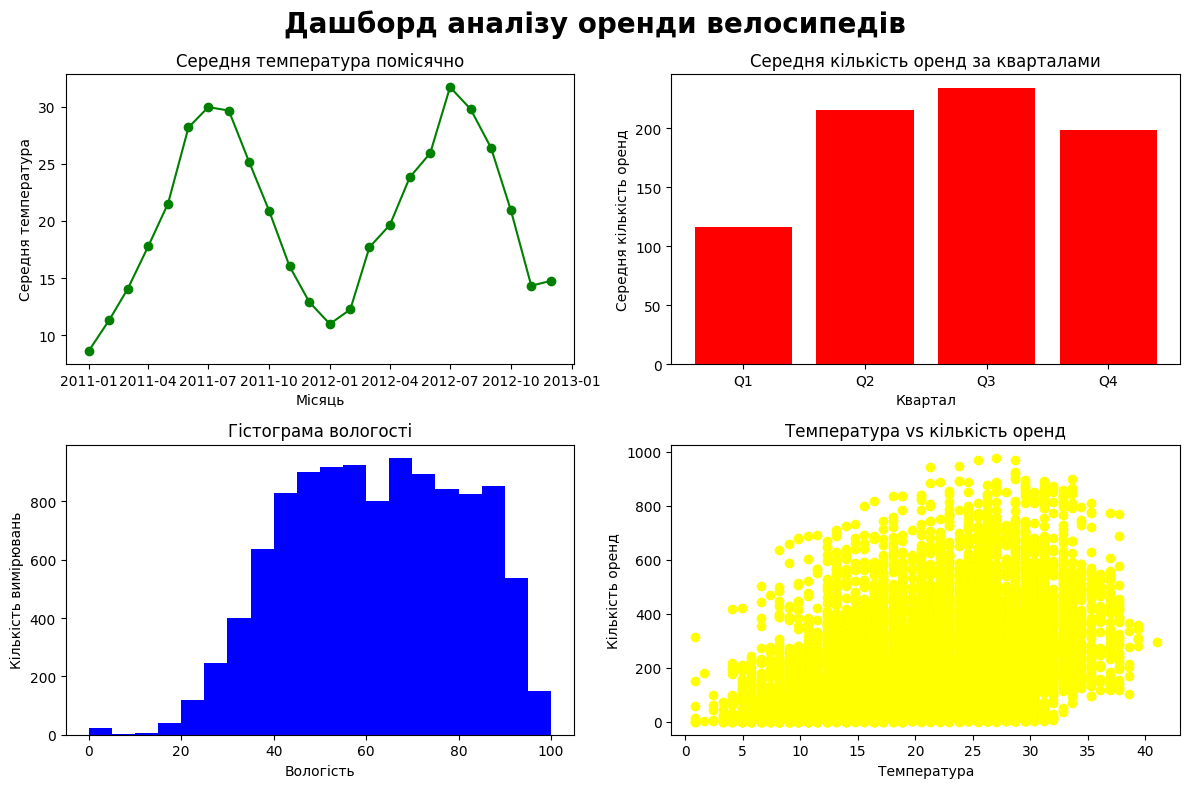

In [41]:
plt.figure(figsize=(12, 8))

plt.suptitle(
    'Дашборд аналізу оренди велосипедів',
    fontsize=20,
    fontweight='bold'
)
# 1. Температура
plt.subplot(2, 2, 1)

monthly_temp = df['temp'].resample('MS').mean()

plt.plot(
    monthly_temp.index,
    monthly_temp.values,
    marker='o',
    color='green'
)

plt.title('Середня температура помісячно')
plt.xlabel('Місяць')
plt.ylabel('Середня температура')


# 2. Квартали
plt.subplot(2, 2, 2)

season_avg = df.groupby('season')['count'].mean()

plt.bar(
    ['Q1', 'Q2', 'Q3', 'Q4'],
    season_avg.values,
    color='red'
)

plt.title('Середня кількість оренд за кварталами')
plt.xlabel('Квартал')
plt.ylabel('Середня кількість оренд')


# 3. Вологість
plt.subplot(2, 2, 3)

plt.hist(
    df['humidity'],
    bins=20,
    color='blue'
)

plt.title('Гістограма вологості')
plt.xlabel('Вологість')
plt.ylabel('Кількість вимірювань')


# 4. Температура та оренди
plt.subplot(2, 2, 4)

plt.scatter(
    df['temp'],
    df['count'],
    color='yellow'
)

plt.title('Температура vs кількість оренд')
plt.xlabel('Температура')
plt.ylabel('Кількість оренд')


plt.tight_layout()
plt.show()

## Завдання 4: Subplots - об'єктно-орієнтований підхід

**Завдання:**
Створіть той самий набір графіків, але використовуючи `fig, ax = plt.subplots()`.

**Дайте відповідь на питання своїми словами**
- Чим відрізняється підхід побудови кількох графіків на одній фігурі з `plt.subplots()` від `plt.subplot()`?

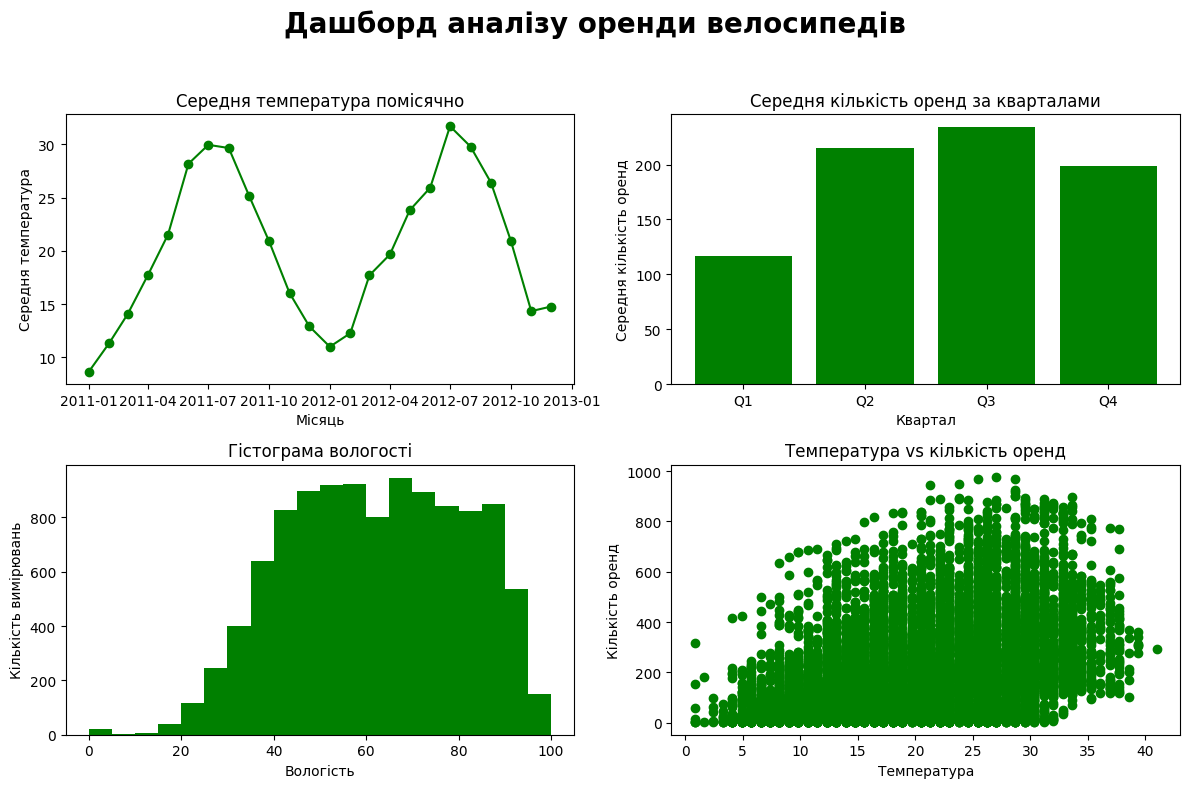

In [45]:

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle(
    'Дашборд аналізу оренди велосипедів',
    fontsize=20,
    fontweight='bold'
)


# 1. Температура
monthly_temp = df['temp'].resample('MS').mean()

ax[0, 0].plot(
    monthly_temp.index,
    monthly_temp.values,
    marker='o',
    color='green'
)

ax[0, 0].set_title('Середня температура помісячно')
ax[0, 0].set_xlabel('Місяць')
ax[0, 0].set_ylabel('Середня температура')


# 2. Квартали
season_avg = df.groupby('season')['count'].mean()

ax[0, 1].bar(
    ['Q1', 'Q2', 'Q3', 'Q4'],
    season_avg.values,
    color='green'
)

ax[0, 1].set_title('Середня кількість оренд за кварталами')
ax[0, 1].set_xlabel('Квартал')
ax[0, 1].set_ylabel('Середня кількість оренд')


# 3. Вологість
ax[1, 0].hist(
    df['humidity'],
    bins=20,
    color='green'
)

ax[1, 0].set_title('Гістограма вологості')
ax[1, 0].set_xlabel('Вологість')
ax[1, 0].set_ylabel('Кількість вимірювань')


# 4. Температура та оренди
ax[1, 1].scatter(
    df['temp'],
    df['count'],
    color='green'
)

ax[1, 1].set_title('Температура vs кількість оренд')
ax[1, 1].set_xlabel('Температура')
ax[1, 1].set_ylabel('Кількість оренд')


# Автоматичне вирівнювання
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()

Головна різниця в тому, що plt.subplot() працює більше через поточний активний графік, а plt.subplots() дає нам окремі об'єкти для керування кожним графіком. Перший варіант зрозуміліший і швидший, але другий можна використовувати для більш складних візуалізацій

## (Опціонально) Завдання 5: Тонкі налаштування форматування графіка

**Завдання:**
Подібно до прикладу, наведеного в лекції, створіть професійно оформлений графік помісячної динаміки оренди з максимальною кількістю деталей та налаштувань. Ваш графік має включати:

**Обов'язкові елементи:**
1. **Три лінії:** середнє, максимум, мінімум за місяцями
2. **Різні стилі ліній:** суцільна, пунктирна, крапкова + різні маркери
3. **Заливка області** між мінімумом та максимумом
4. **Дві анотації:** для найвищого та найнижчого середнього значення
5. **Горизонтальна лінія** середнього за весь рік
6. **Двошарова сітка:** основна та допоміжна
7. **Стилізована легенда** з тінню
8. **Текстовий блок** зі статистикою в кутку графіка
9. **Професійне оформлення:** заголовки, підписи осей з жирним шрифтом

**Результат:** Графік повинен виглядати як готова ілюстрація для бізнес-звіту або наукової публікації.

Приклад очікуваного результату.
![](https://drive.google.com/uc?id=1YoJByivzlqncEF2zbWu3EhGSZ7XRme8T)


**Питання для інтерпретації:**
1. Яка перевага додавання анотацій на графік?
2. Для чого використовується fill_between()?
3. Як текстовий блок допомагає в інтерпретації даних?